temp c=19.81	temp f=67.66
temp c=19.81	temp f=67.66
temp c=19.81	temp f=67.66
temp c=19.81	temp f=67.66
temp c=19.81	temp f=67.66
temp c=19.73	temp f=67.51
temp c=19.81	temp f=67.66
temp c=18.61	temp f=65.49
temp c=17.66	temp f=63.79
temp c=17.66	temp f=63.79
temp c=16.11	temp f=61.00
temp c=16.28	temp f=61.31
temp c=16.03	temp f=60.85
temp c=16.11	temp f=61.00
temp c=17.06	temp f=62.71
temp c=16.72	temp f=62.09
temp c=15.77	temp f=60.38
temp c=15.51	temp f=59.91
temp c=14.73	temp f=58.51
temp c=14.82	temp f=58.67
temp c=15.77	temp f=60.38
temp c=16.37	temp f=61.47
temp c=16.63	temp f=61.93
temp c=16.97	temp f=62.55
temp c=17.32	temp f=63.17
temp c=17.40	temp f=63.33
temp c=17.58	temp f=63.64
temp c=17.66	temp f=63.79
temp c=17.75	temp f=63.95
temp c=17.83	temp f=64.10
temp c=17.83	temp f=64.10
temp c=18.95	temp f=66.11
temp c=22.40	temp f=72.33
temp c=23.80	temp f=74.83
temp c=24.32	temp f=75.78
temp c=24.41	temp f=75.93
temp c=24.41	temp f=75.93
temp c=24.67	temp f=76.41
temp c=24.76

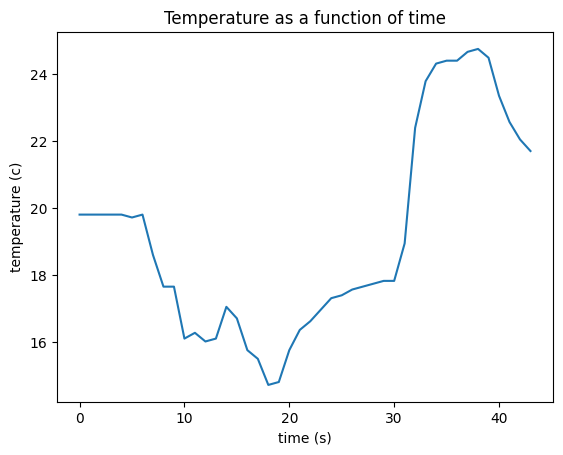

In [3]:
from gpiozero import Button, MCP3008
import math
from time import sleep
from matplotlib import pyplot as plt

temp_pin = MCP3008(channel = 0)
temp_but = Button(18)
x = []
y = []

def print_cond(cond):
    if cond == 1:
        print("appropriate")
    else:
        print("hot")

def loop():
    status = 1
    tmp = 1
    seconds = 0
    while True:
        ana = temp_pin.value
        vr = float(ana)*3.3
        rt = 10000*vr/(3.3-vr)
        new_temp = 1/((math.log(rt/10000)/3950) + (1/(273.15+25)))
        c = new_temp-273.15
        f = c *(9/5)+32
        print("temp c={:.2f}\ttemp f={:.2f}".format(c,f))
        tmp = not temp_but.is_pressed
        if tmp != status:
            print_cond(tmp)
            status = tmp
        x.append(seconds)
        y.append(c)
        seconds+=1
        sleep(1)
    
if __name__ == "__main__":
    try:
        loop()
    except KeyboardInterrupt:
        plt.plot(x,y)
        plt.xlabel("time (s)")
        plt.ylabel("temperature (c)")
        plt.title("Temperature as a function of time")
        plt.show()
        temp_pin.close()
        temp_but.close()

#Held Ice block, released. gripped sensor head, released.